In [1]:
from ml_article_tagging.config import RAW_DATA_DIR

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
from wordcloud import WordCloud, STOPWORDS
import pandas as pd

### Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv(RAW_DATA_DIR / "train_dataset.csv")
df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


In [3]:
len(df)

764

In [4]:
# Checking data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           764 non-null    int64 
 1   created_on   764 non-null    object
 2   title        764 non-null    object
 3   description  764 non-null    object
 4   tag          764 non-null    object
dtypes: int64(1), object(4)
memory usage: 30.0+ KB


In [5]:
# Checking for missing values
df.isnull().sum()

id             0
created_on     0
title          0
description    0
tag            0
dtype: int64

In [6]:
# Duplicates Check
df.duplicated().sum()

np.int64(0)

In [7]:
df.tag.value_counts()

tag
natural-language-processing    310
computer-vision                285
other                          106
mlops                           63
Name: count, dtype: int64

/tmp/ipykernel_16681/2835566648.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tag_counts.index, rotation=0, fontsize=8)


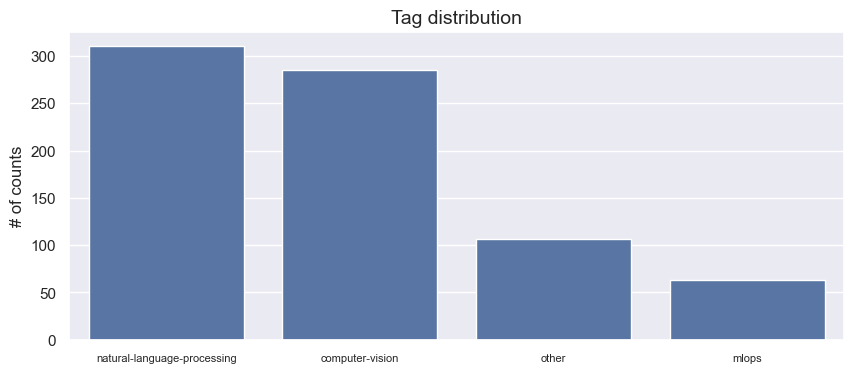

In [8]:
# tag value count barplot
tag_counts = df.tag.value_counts()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=tag_counts.index, y=tag_counts.values)
ax.set_xticklabels(tag_counts.index, rotation=0, fontsize=8)
plt.title("Tag distribution", fontsize=14)
plt.xlabel("")
plt.ylabel('# of counts', fontsize=12)
plt.show()

In [9]:
df["text"] = df["title"] + " " + df["description"]

In [ ]:
# World Cloud
import ipywidgets as widgets
from IPython.display import display

def plot_wordclod(tag):
    subset = df[df.tag == tag]
    text = subset.text.values

    fig, ax = plt.subplots(figsize=(6,6), facecolor="black") 

    cloud = WordCloud(
        stopwords=STOPWORDS,
        background_color="black",
        collocations=False, 
        width=600,
        height=400
    ).generate(" ".join(text))

    ax.imshow(cloud)
    ax.axis("off")

    plt.tight_layout(pad=0)
    plt.show()
    

tag_dropdown = widgets.Dropdown(
    options=df.tag.unique(),
    description="Tag:",
    value=df.tag.unique()[0]
)

widgets.interact(plot_wordclod, tag=tag_dropdown)

interactive(children=(Dropdown(description='Tag:', options=('computer-vision', 'other', 'natural-language-proc…

<function __main__.plot_wordclod(tag)>